<a href="https://colab.research.google.com/github/tamamori3180-hash/GCI-/blob/main/%E3%83%89%E3%83%A9%E3%83%95%E3%83%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [ベースライン] 第2回データ分析コンペティション：NFL Draft Prediction

　本ノートブックでは、「スポーツパフォーマンステストおよび選手情報をもとに、NFLドラフト指名の有無（Drafted）を予測する」タスクのベースラインモデルを構築します。

　ベースラインモデルとは、与えられた機械学習タスクに対して、まず最初に構築されるシンプルなモデルであり、今後のモデル開発・性能向上の出発点となるものです。

　本ノートブックを上から順番に実行していけば、正常に提出できる予測ファイルが作成されます。

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [ ]:
# Google Driveのマウント（Colab上で自分のデータにアクセスするための設定です）
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# モジュールのインポート
import numpy as np  # 数値計算や配列操作を行うためのライブラリ
import pandas as pd  # 表形式のデータを扱うためのライブラリ
import matplotlib.pyplot as plt  # データ可視化のための基本的なグラフ描画ライブラリ
import seaborn as sns  # 高機能な統計グラフを描画するライブラリ
from sklearn.preprocessing import LabelEncoder  # カテゴリ変数を数値に変換するエンコーダ
from sklearn.ensemble import RandomForestClassifier  # ランダムフォレストによる分類器
from sklearn.model_selection import StratifiedKFold  # 層化K分割交差検証を行うクラス
from sklearn.metrics import roc_auc_score  # ROC AUCスコアを計算する評価指標

## 2. データ読み込み

In [ ]:
# 読み込むデータが格納されたディレクトリのパス（※必要に応じて変更の必要があります）
PATH = '/content/drive/My Drive/GCI/winter/competition_2/data/'

train = pd.read_csv(PATH + 'train.csv')  # 学習用データの読み込み
test = pd.read_csv(PATH + 'test.csv')    # テスト用データの読み込み

###情報

In [ ]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


　訓練データのデータ数は2781、変数は16、テストデータのデータ数は696、変数は15であることが分かりました。  
　ここで、テストデータの変数が1つ少ないのは、予測対象である目的変数が無いからです。  

In [ ]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


　pandasのDataFrameは.info()を使用することで、詳細な情報を確認できます。

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                696 non-null    int64  
 1   Year              696 non-null    int64  
 2   Age               581 non-null    float64
 3   School            696 non-null    object 
 4   Height            696 non-null    float64
 5   Weight            696 non-null    float64
 6   Sprint_40yd       667 non-null    float64
 7   Vertical_Jump     553 non-null    float64
 8   Bench_Press_Reps  512 non-null    float64
 9   Broad_Jump        549 non-null    float64
 10  Agility_3cone     449 non-null    float64
 11  Shuttle           468 non-null    float64
 12  Player_Type       696 non-null    object 
 13  Position_Type     696 non-null    object 
 14  Position          696 non-null    object 
dtypes: float64(9), int64(2), object(4)
memory usage: 81.7+ KB


In [ ]:
train.describe()

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted
count,2781.000000,2781.000000,2781.000000,2781.000000,2636.000000,2227.000000,2060.000000,2200.000000,1811.000000,1869.000000,2781.000000
mean,2013.838907,21.991006,1.873590,109.502026,4.764818,83.506349,20.236408,291.985700,7.230447,4.399422,0.648328
std,3.083247,0.888063,0.067178,20.307239,0.299343,10.710691,6.410662,23.924666,0.410686,0.263851,0.477578
min,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,3.820000,0.000000
25%,2011.000000,21.000000,1.828800,92.986436,4.530000,76.200000,16.000000,276.860000,6.930000,4.200000,0.000000
50%,2014.000000,22.000000,1.879600,104.779837,4.680000,83.820000,20.000000,294.640000,7.130000,4.350000,1.000000
75%,2017.000000,22.189427,1.930400,124.284309,4.950000,91.440000,24.000000,307.340000,7.490000,4.560000,1.000000
max,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,5.560000,1.000000


「Weight」のMAXが外れ値であるか調べる為にEDAで箱ひげ図を用いたが見られなかった。

###カテゴリ

In [ ]:
train.describe(include="object")

,School,Player_Type,Position_Type,Position
count,2781,2781,2781,2781
unique,236,3,7,20
top,Alabama,offense,backs_receivers,WR
freq,73,1445,1010,395


In [ ]:
train.value_counts(["Player_Type"])

,count
Player_Type,
offense,1445
defense,1241
special_teams,95


In [ ]:
train.value_counts(["Position_Type"])

,count
Position_Type,
backs_receivers,1010
defensive_back,541
offensive_lineman,435
defensive_lineman,391
line_backer,309
kicking_specialist,82
other_special,13


In [ ]:
train.value_counts(["Position"])

,count
Position,
WR,395
CB,328
RB,250
OT,212
DT,200
OLB,191
DE,191
QB,162
TE,162


In [ ]:
train[train["Drafted"] == 1]

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2775,2775,2011,24.0,Arizona,1.8796,119.294793,4.65,77.47,30.0,287.02,7.11,4.28,defense,line_backer,OLB,1.0
2777,2777,2012,21.0,Washington,1.8796,157.850145,5.30,66.04,35.0,261.62,NaN,NaN,defense,defensive_lineman,DT,1.0
2778,2778,2011,21.0,Wisconsin,1.9558,131.541787,4.81,93.98,34.0,304.80,6.88,4.21,defense,defensive_lineman,DE,1.0
2779,2779,2017,22.0,Indiana,1.9304,138.345673,5.24,71.12,26.0,256.54,7.52,4.68,offense,offensive_lineman,OG,1.0


## 3. EDA

　**EDA（探索的データ分析）**は、モデル構築の前にデータの構造や特徴を把握するための重要なステップです。

　この段階では、データに含まれる傾向やパターン、外れ値、欠損値、分布の偏りなどを明らかにします。たとえば、ある変数に極端な値があったり、特定のカテゴリにデータが偏っていたりすることがあります。こうした特徴を把握することで、予測に悪影響を及ぼす要因や、有効な特徴量を見つけることができます。

　EDAを行うことで、「欠損値によって学習が進まない」「外れ値の影響でモデルが不安定になる」といった問題を事前に発見し、対処できます。これにより、後工程での手戻りを減らし、効率的な前処理や特徴量設計が可能になります。

　また、EDAで得た知見は、その後のモデル設計やパラメータ調整にも役立ちます。機械学習コンペティションなどでは、最終的なスコア向上にもつながる重要なプロセスです。

　まずは欠損値を確認しておきましょう。機械学習を用いたデータ分析に取り組む上で欠損値の確認は必須となっています。なぜなら、ほとんどの機械学習モデルは欠損値を含むデータに対して学習や予測ができず、エラーとなってしまうからです。

In [ ]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [ ]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


　「Age」「Sprint_40yd」「Vertical_Jump」「Bench_Press_Reps」「Broad_Jump」「Agility_3cone」「Shuttle」列に欠損値があることが分かりました。これらは後で対処することとします。  

　次にドラフト選出された選手の数を見てみましょう。

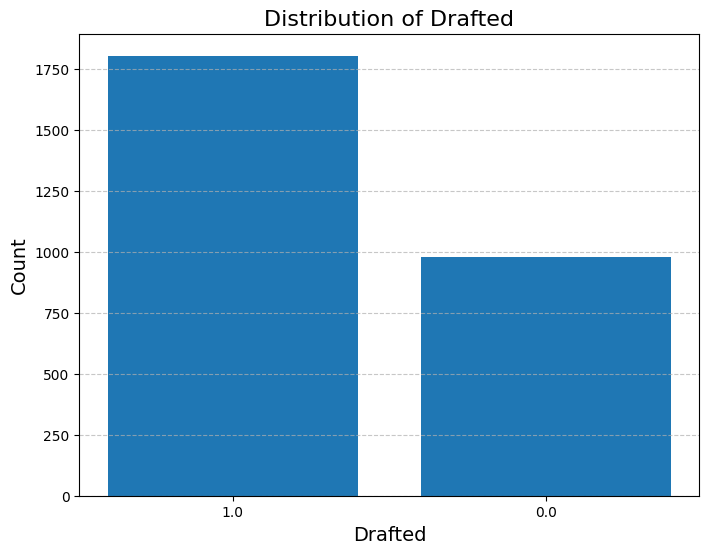

In [ ]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

　「Drafted」列が1である選手の方が0である選手より多いことが分かりました。割合を見てみましょう。

In [ ]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


　ドラフト選出されなかった選手は約35%、ドラフト選出された選手は約65%いることが分かりました。

　その他の特徴量についてもEDAしていきます。まずは「Id」「Drafted」列を除く数値データについて可視化してみましょう。

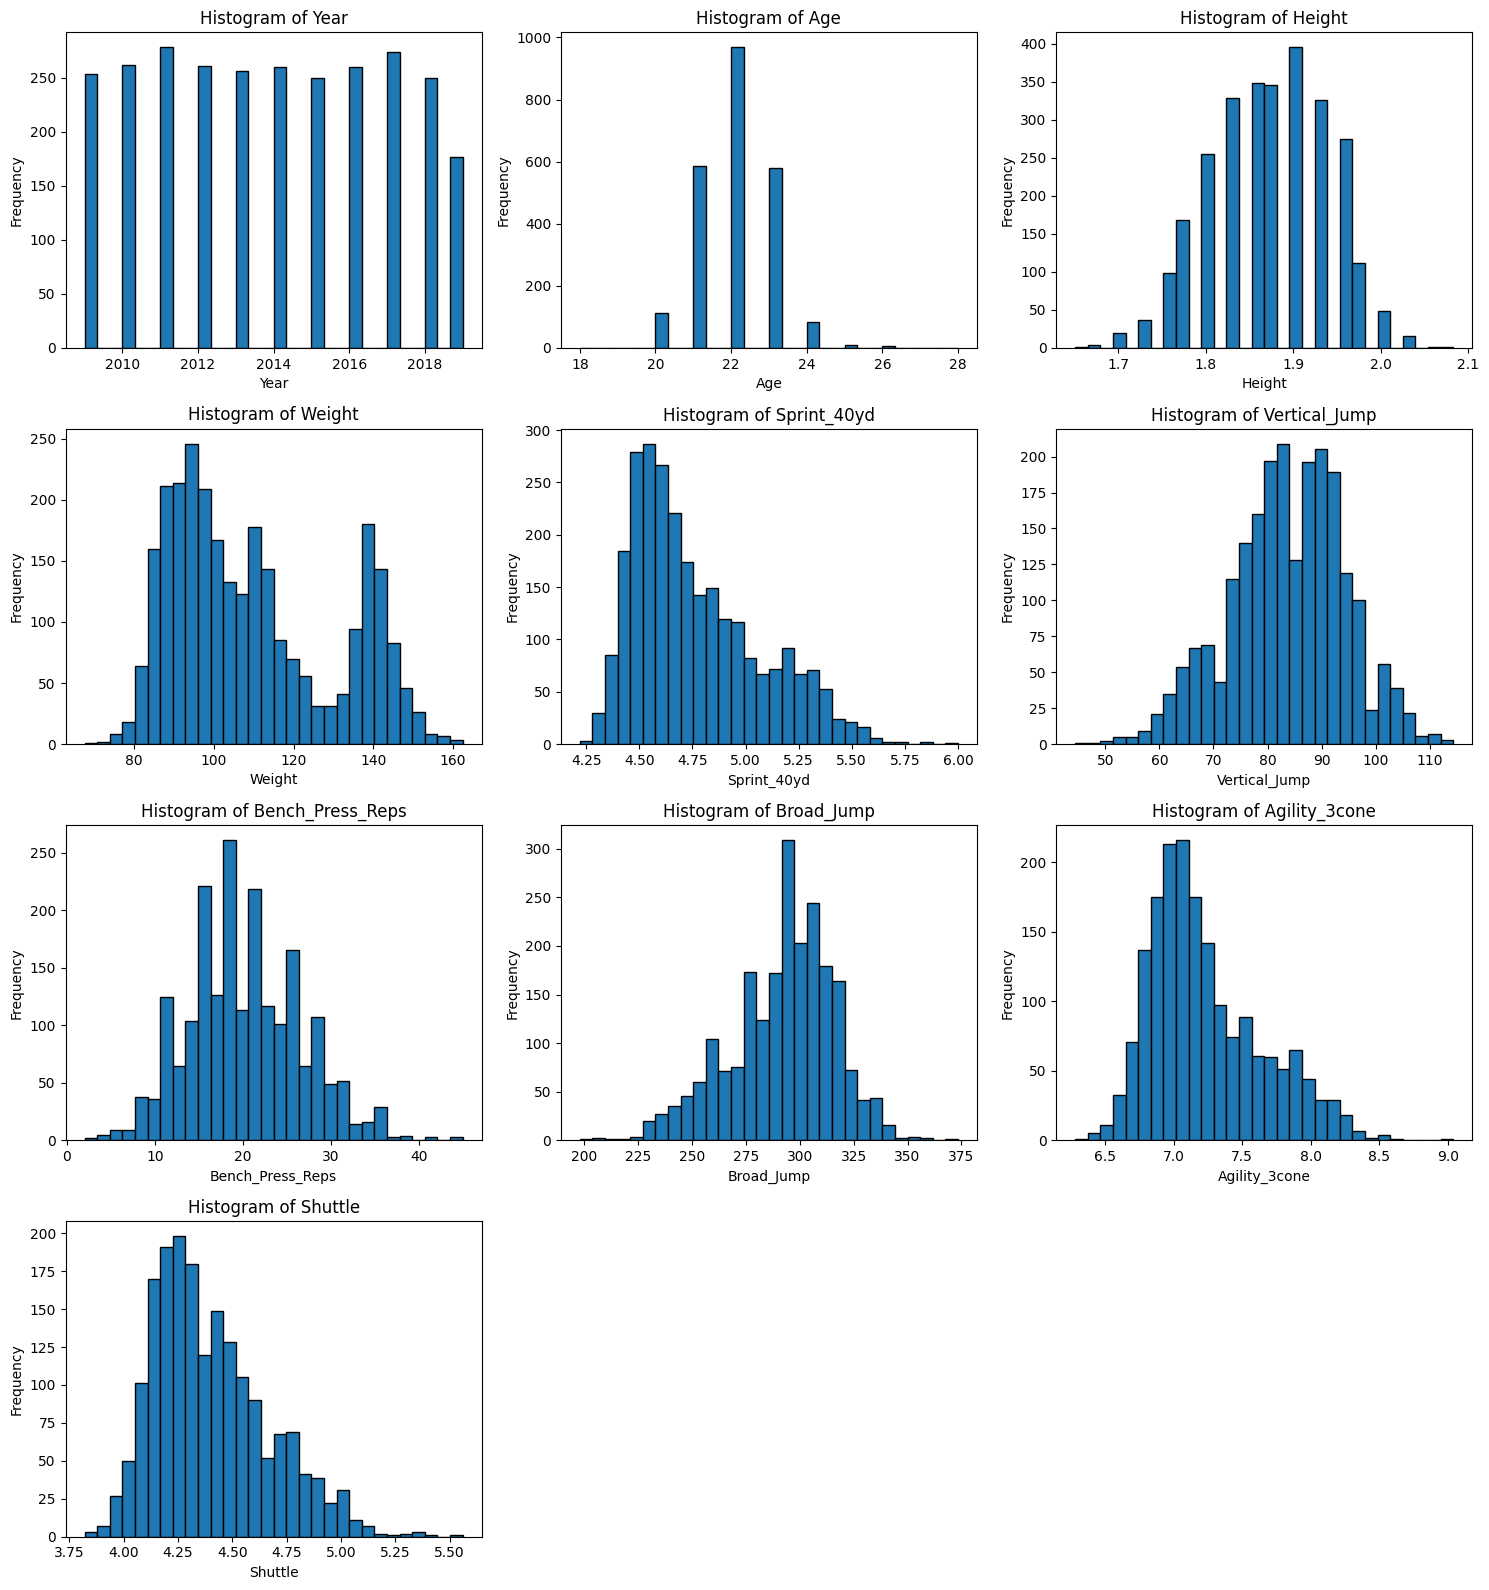

In [ ]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# プロット
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

体重は80kg〜115kg付近に多くの選手が集中していますが、135kg〜150kg付近にも「ラインマン」と思われる重量級選手の山があり、二峰性の分布に近い形をしています。

　数値データの相関行列をヒートマップで確認してみましょう。

###相関分析

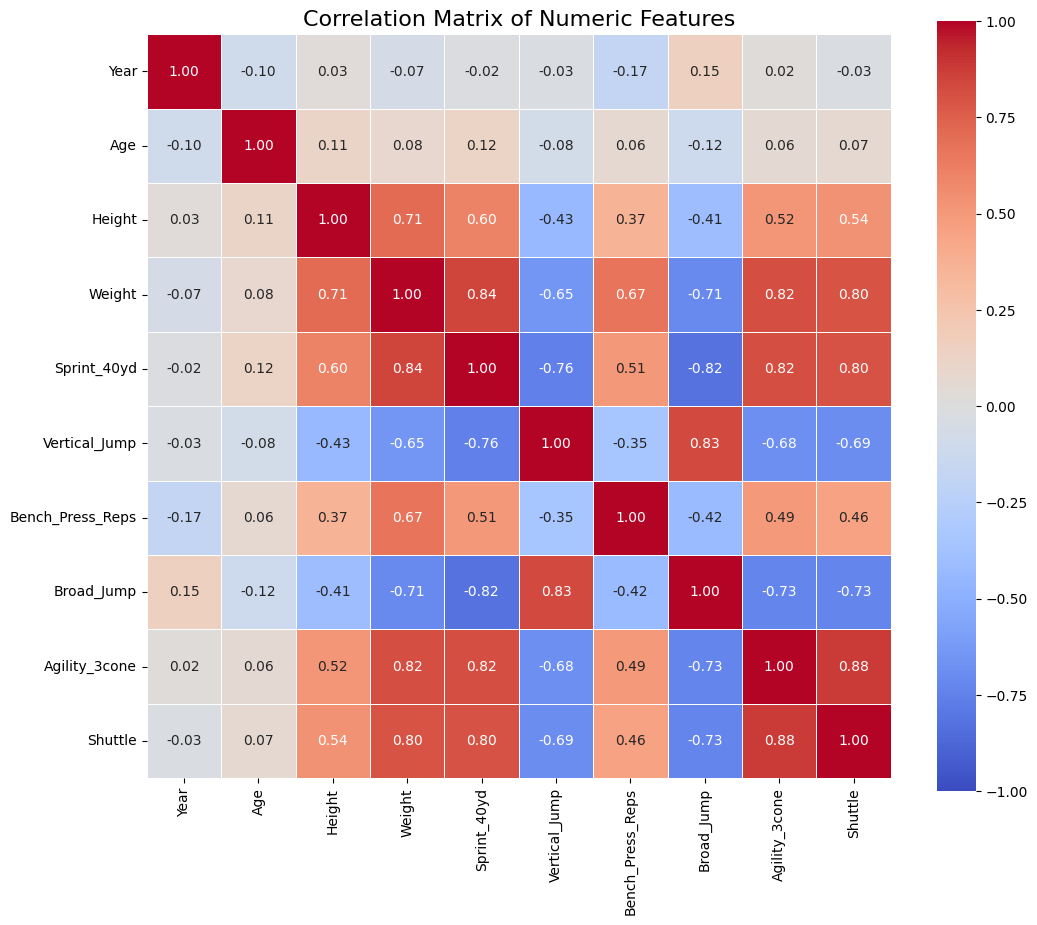

In [ ]:
# 数値列だけを取り出す（Id, Drafted列は除く）
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# 相関行列を計算
corr_matrix = numeric_cols.corr()

# ヒートマップをプロット
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

　「Agility_3cone」列と「Shuttle」列の相関係数は0.88であり、強い正の相関関係があることが分かります。これらのスポーツテストでは、似た筋肉や動作が使われている可能性が考えられます。

　一方、「Sprint_40yd」列と「Broad_Jump」列の相関係数は-0.82で、強い負の相関関係が見られました。どちらも主に脚の力を使う種目であるため、通常はスコアが比例する（正の相関になる）と予想されますが、実際には逆の関係が見られています。この理由を探るため、「Sprint_40yd」列を可視化してみます。


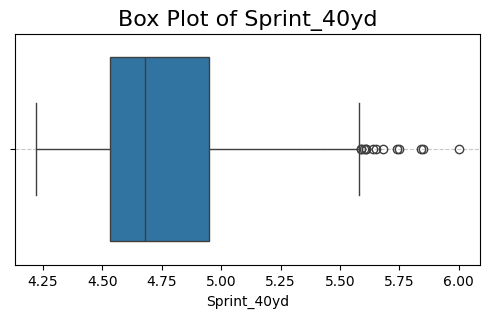

In [ ]:
# 箱ひげ図を描画
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

　可視化されたグラフを見ると、「Sprint_40yd」列の値はおおよそ4.25から6.00の範囲に分布していることがわかります。この数値はスコアではなく実際の走行タイムである可能性が高そうです。40ヤード（約36メートル）を走るタイムとして、中央値が約4.7秒であるのは妥当です。

　つまり、「Sprint_40yd」列の値が小さいほど速く走れたことを意味し、 数値が小さい＝パフォーマンスが高い という点で、他の 数値が大きいほど良い スコアとは逆の関係になっていたのです。

 データを可視化することで、「なぜ負の相関があるのか？」という疑問を解決することができました。

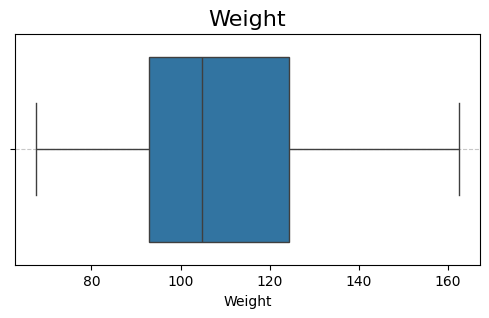

In [ ]:
# Weight 箱ひげ図を描画
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Weight'])

plt.title('Weight', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

外れ値はみられなかった。

　次は、カテゴリデータについて可視化してみましょう。

In [ ]:
# カテゴリデータを抽出
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# 各列の水準数を取得
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


　Schoolは水準数が236とかなり多く、可視化すると潰れて見づらいのでここでは可視化しません。

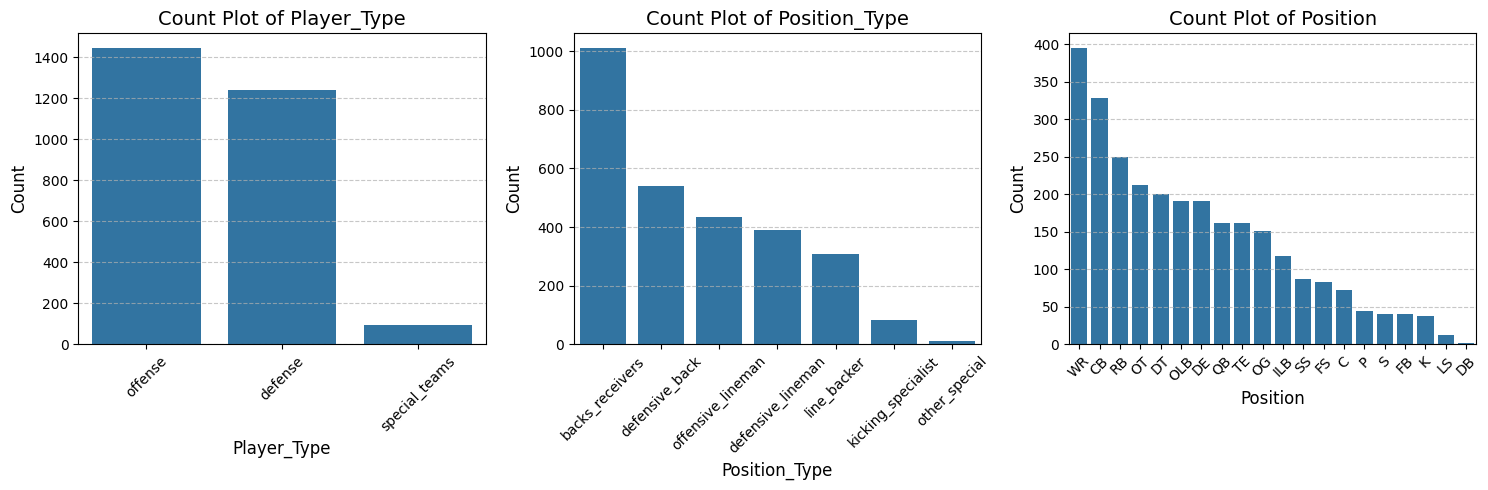

In [ ]:
# カテゴリデータ（object型またはcategory型）を抽出し、School列を除外
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数でカウントプロット
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

　水準によってデータ数に大きな差があるのが分かりました。例えば「Player_Type」列については、「special_teams」のデータ数がかなり少ないことが分かります。

　次に、カテゴリデータについて、各水準の「Drafted列」の平均値を可視化してみましょう。この可視化を行うことで、どのポジションの選手がドラフトされやすいのかを視覚的に理解することができます。

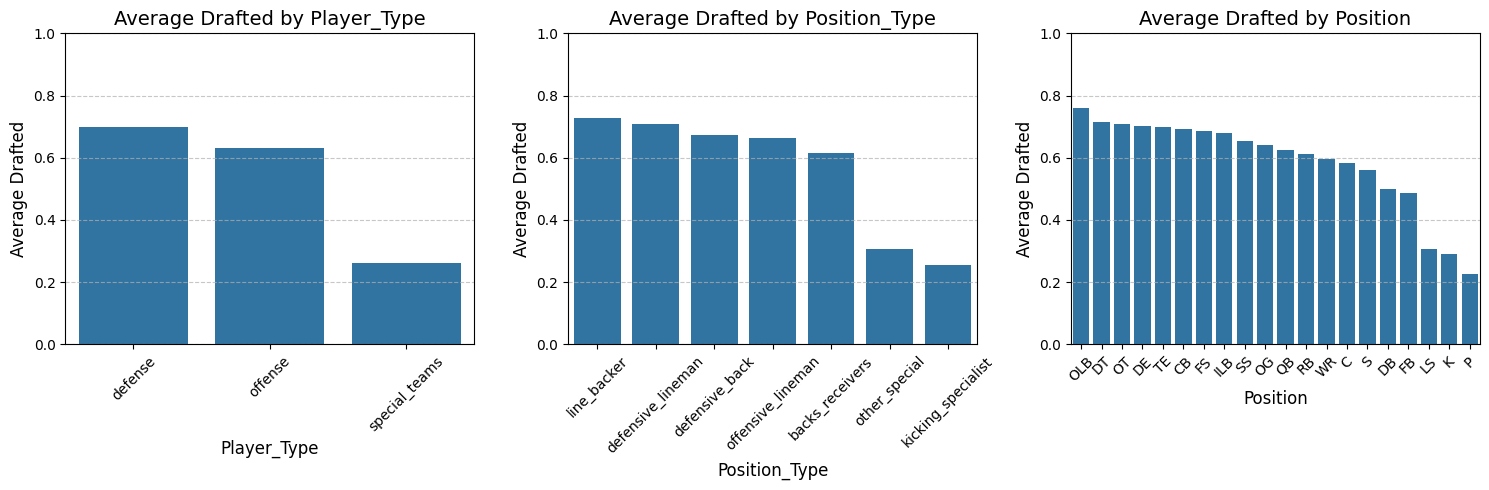

In [ ]:
# カテゴリ変数（object型またはcategory型）を抽出し、School列を除外
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# グラフ描画準備
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 各カテゴリ変数ごとに Drafted 列の平均を棒グラフで描画
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


　「Player_Type」列が「special_teams」である選手は他の選手と比べてドラフト選出される割合がかなり低いことが分かります。  
　また、「Position_Type」列が「other_special」「kicking_specialist」である選手、「Position」列が「LS」「K」「P」である選手もドラフト選出される割合が低いことが分かります。

## 4. 前処理

　欠損補完、エンコーディングを行います。  
　本ノートブックでは、水準数が比較的多いカテゴリデータを特徴量から外すことにします。つまり、ここでは「School」列（水準数: 236）を削除します。（※「School」列の値が「Drafted」列の値に影響することも考えられます。より深く追求する際に特徴量に含めてみましょう。）また、「Id」列はドラフトの選出に関係がないと予想されるため、削除します。

In [ ]:
# 使わない列の削除
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id","School"])

#１回目

##処理

###Age

相関分析より、「Age」に強い相関はみられないから欠損値削除しても構わない？

→他のカラムのデータも消えてしまうからダメ

In [ ]:
train[train["Age"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
16,2019,NaN,1.8796,95.707990,NaN,NaN,8.0,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
17,2012,NaN,1.9050,102.058283,5.06,80.01,NaN,256.54,7.14,4.37,offense,backs_receivers,QB,0.0
25,2018,NaN,1.8034,88.450512,4.62,NaN,17.0,NaN,NaN,NaN,defense,defensive_back,S,0.0
28,2016,NaN,1.9050,99.336729,5.05,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,P,0.0
30,2012,NaN,1.8542,100.243914,4.91,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,K,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,2010,NaN,1.9050,99.336729,5.04,83.82,NaN,269.24,7.08,4.33,offense,backs_receivers,QB,0.0
2761,2009,NaN,1.8034,84.821773,4.52,NaN,NaN,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
2764,2009,NaN,1.9050,102.058283,4.82,80.01,26.0,281.94,7.00,4.47,offense,backs_receivers,QB,0.0
2765,2018,NaN,1.8034,90.264882,4.64,85.09,11.0,309.88,NaN,NaN,offense,backs_receivers,RB,0.0


In [ ]:
train1 = train
test1 = test

# 1. Trainデータをもとに、年度(Year)ごとのAgeの平均値を算出
age_mean_by_year = train1.groupby('Year')['Age'].mean()

# 2. 欠損値を補完する関数を定義
def fill_age(row, source_means):
    # Ageが欠損(NaN)の場合
    if pd.isnull(row['Age']):
        # その年度の平均値を返す（万が一その年度が辞書にない場合は元のNaNを返す）
        return source_means.get(row['Year'], row['Age'])
    # 欠損していない場合はそのままの値を返す
    return row['Age']

# 3. Trainデータへの適用
train1['Age'] = train1.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)

# 4. Testデータへの適用（Trainデータの平均値を使用）
test1['Age'] = test1.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)

# 確認
print("TrainデータのAge欠損数:", train1['Age'].isnull().sum())
print("TestデータのAge欠損数:", test1['Age'].isnull().sum())

TrainデータのAge欠損数: 0
TestデータのAge欠損数: 0



###Sprint_40yd

In [ ]:
train1[train1["Sprint_40yd"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
16,2019,21.776860,1.8796,95.707990,NaN,NaN,8.0,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
36,2018,21.000000,1.8796,92.986436,NaN,99.06,11.0,325.12,6.72,4.23,defense,defensive_back,DB,0.0
45,2019,21.776860,1.7780,96.161582,NaN,NaN,27.0,NaN,NaN,NaN,offense,backs_receivers,RB,0.0
68,2017,21.000000,1.9304,97.068767,NaN,NaN,NaN,NaN,NaN,NaN,offense,backs_receivers,QB,1.0
130,2017,22.000000,1.9812,140.613635,NaN,NaN,25.0,NaN,NaN,NaN,offense,offensive_lineman,OT,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2677,2017,21.853659,1.9050,122.923532,NaN,NaN,NaN,NaN,NaN,NaN,defense,defensive_lineman,DE,0.0
2692,2019,21.776860,2.0066,146.963928,NaN,NaN,27.0,289.56,8.07,4.50,offense,offensive_lineman,OT,0.0
2694,2018,23.000000,1.9304,138.345673,NaN,NaN,NaN,NaN,NaN,NaN,offense,offensive_lineman,C,1.0
2697,2017,22.000000,1.9050,99.790321,NaN,NaN,20.0,NaN,NaN,NaN,defense,defensive_back,CB,1.0


相関分析より、「Weight」が最も強い正の相関を持っていた。タイムが遅い人は体重が重いことが読み取れた。

体重別に平均を求め補完する。
「Broad_Jump」が次いで負の相関を持っていたが、欠損値を持っている為今回は体重にした。

分割方法の比較:

等頻度分割 (qcut): 10等分した場合、各ビンのサンプル数は250〜290程度で安定しますが、体重の範囲（kg幅）はビンによってバラバラになります。

等間隔分割 (cut, 5kg刻み): 物理的な意味（「5kg違うとタイムがどう変わるか」）が捉えやすいですが、両端（70-75kgや160kg以上）のサンプル数が極端に少なくなります（5件や2件など）。サンプル数が少ないビンで平均値を計算すると、信頼性が低くなります。

サンプル数を確保しつつ、体重の変動によるタイムへの影響を細かく捉えるため、「分位点（Quantile）による分割」を行う。

In [ ]:
# データの読み込み
train2 = train1
test2 = test1

# --- 1. Sprint_40ydの補完 ---
# Weightを10等分したグループを作成 (Trainデータ基準)
# retbins=Trueにすることで、区切った境界値(bins)を取得できます
train2['Weight_Group'], bins = pd.qcut(train2['Weight'], q=10, retbins=True, labels=False)

# 各グループごとのSprint_40ydの平均値を計算
sprint_means = train2.groupby('Weight_Group')['Sprint_40yd'].mean()

print("体重グループごとの平均タイム:")
print(sprint_means)

# 補完関数の定義
def fill_sprint(row, bins, means):
    if pd.isnull(row['Sprint_40yd']):
        # そのデータの体重がどのビンに入るか判定
        # pd.cutを使って、作成したbinsに基づいて分類
        bin_idx = pd.cut([row['Weight']], bins=bins, labels=False, include_lowest=True)[0]

        # ビンが見つかればその平均値を、見つからなければ全体平均などを返す(安全策)
        if pd.notnull(bin_idx):
             return means[bin_idx]
        else:
             return means.mean() # 万が一範囲外の場合
    return row['Sprint_40yd']

# Trainデータの補完
train2['Sprint_40yd'] = train2.apply(lambda row: fill_sprint(row, bins, sprint_means), axis=1)

# Testデータの補完 (Trainで作ったbinsとmeansを使用)
test2['Sprint_40yd'] = test2.apply(lambda row: fill_sprint(row, bins, sprint_means), axis=1)

# 一時カラムの削除
train2.drop(columns=['Weight_Group'], inplace=True)

# 確認
print("補完後の欠損数(Train):", train2['Sprint_40yd'].isnull().sum())
print("補完後の欠損数(Test):", test2['Sprint_40yd'].isnull().sum())

体重グループごとの平均タイム:
Weight_Group
0    4.514315
1    4.522667
2    4.548308
3    4.592731
4    4.667820
5    4.717490
6    4.755095
7    4.884672
8    5.170806
9    5.269198
Name: Sprint_40yd, dtype: float64
補完後の欠損数(Train): 0
補完後の欠損数(Test): 0


###Bench_Press_Reps

In [ ]:
train2[train2["Bench_Press_Reps"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
4,2016,21.000000,1.8796,92.079251,4.640000,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0
8,2012,22.000000,1.9558,143.788781,5.360000,74.93,NaN,259.08,7.81,4.90,offense,offensive_lineman,OG,0.0
13,2012,22.000000,1.7780,92.532843,4.480000,93.98,NaN,307.34,NaN,NaN,defense,defensive_back,CB,1.0
17,2012,22.189427,1.9050,102.058283,5.060000,80.01,NaN,256.54,7.14,4.37,offense,backs_receivers,QB,0.0
26,2009,23.000000,1.8796,97.522360,5.020000,81.28,NaN,276.86,7.10,4.42,offense,backs_receivers,QB,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,2010,22.013825,1.9050,99.336729,5.040000,83.82,NaN,269.24,7.08,4.33,offense,backs_receivers,QB,0.0
2757,2009,21.000000,1.8796,102.058283,4.810000,77.47,NaN,271.78,7.06,4.47,offense,backs_receivers,QB,1.0
2761,2009,22.089109,1.8034,84.821773,4.520000,NaN,NaN,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
2770,2011,23.000000,1.8796,103.872653,4.630000,86.36,NaN,294.64,6.85,4.09,offense,backs_receivers,QB,1.0


ゴールキーパーが高い値なのでは？

ポジションごとにデータを見てみよう

ポジション別ベンチプレス平均回数 (降順):
Position
DT     27.944099
OG     26.023810
C      25.950820
OT     24.028902
DE     23.755102
OLB    22.618421
FB     22.205882
ILB    21.842105
TE     20.048000
RB     19.546729
P      19.500000
QB     18.555556
LS     17.875000
SS     17.774648
K      17.000000
S      16.903226
FS     16.231884
WR     14.524430
CB     14.518657
DB     12.500000
Name: Bench_Press_Reps, dtype: float64


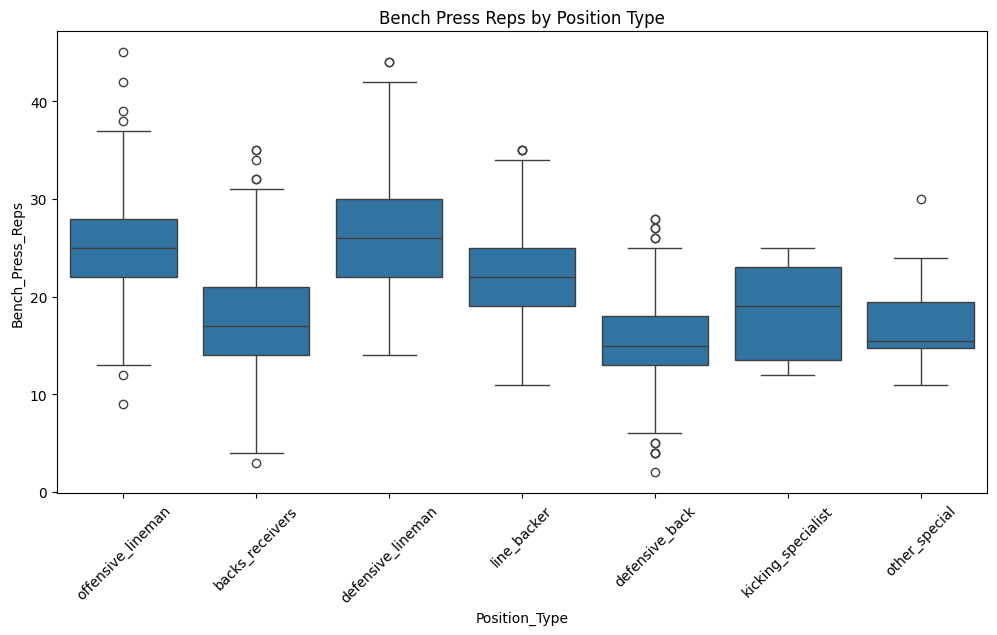

In [ ]:
# データの読み込み
train3 = train2
test3 = test2

# --- 分析: ポジション別の分布を確認 ---
plt.figure(figsize=(12, 6))
# Position_Typeごとの箱ひげ図
sns.boxplot(x='Position_Type', y='Bench_Press_Reps', data=train3)
plt.title('Bench Press Reps by Position Type')
plt.xticks(rotation=45)
# plt.show() # ノートブック環境で表示する場合

# ポジション(詳細)ごとの平均値を確認
print("ポジション別ベンチプレス平均回数 (降順):")
print(train3.groupby('Position')['Bench_Press_Reps'].mean().sort_values(ascending=False))

In [ ]:
train3[train3["Position"] == "DB"]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
36,2018,21.0,1.8796,92.986436,4.548308,99.06,11.0,325.12,6.72,4.23,defense,defensive_back,DB,0.0
1404,2018,21.0,1.8542,91.172066,4.460000,83.82,14.0,307.34,NaN,NaN,defense,defensive_back,DB,1.0


In [ ]:
train[train["Position"] == "DB"]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
36,2018,21.0,1.8796,92.986436,4.548308,99.06,11.0,325.12,6.72,4.23,defense,defensive_back,DB,0.0
1404,2018,21.0,1.8542,91.172066,4.460000,83.82,14.0,307.34,NaN,NaN,defense,defensive_back,DB,1.0


「Position_Type」のグループ内で、ポジションごとに明確な差が見られたため「Position」で区別する。

しかし、データが極端に少ないポジションがあるため、
基本はPositionで埋めて、データがない場合のみPosition_Typeや全体の中央値を使う

In [ ]:
# 1. 統計量の辞書を作成
# (A) 詳細ポジションごとの中央値
position_medians = train3.groupby('Position')['Bench_Press_Reps'].median()
# (B) 大分類ごとの中央値 (バックアップ用)
type_medians = train3.groupby('Position_Type')['Bench_Press_Reps'].median()
# (C) 全体の中央値 (最終バックアップ)
global_median = train3['Bench_Press_Reps'].median()

# 2. 補完関数の定義
def fill_bench_smart(row, pos_meds, type_meds, global_med):
    if pd.isnull(row['Bench_Press_Reps']):
        # ステップ1: Positionで探す
        if row['Position'] in pos_meds.index:
            return pos_meds[row['Position']]

        # ステップ2: なければPosition_Typeで探す
        elif row['Position_Type'] in type_meds.index:
            return type_meds[row['Position_Type']]

        # ステップ3: それでもなければ全体中央値
        else:
            return global_med

    return row['Bench_Press_Reps']

# 3. 適用
train3['Bench_Press_Reps'] = train3.apply(
    lambda row: fill_bench_smart(row, position_medians, type_medians, global_median), axis=1)

test3['Bench_Press_Reps'] = test3.apply(
    lambda row: fill_bench_smart(row, position_medians, type_medians, global_median), axis=1)

print("補完完了")

補完完了


相関分析より、「Agility_3cone」「Shuttle」は体重に比例している。

###Agility_3cone

In [ ]:
train3[train3["Agility_3cone"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
1,2011,24.0,1.8288,87.089735,4.310000,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
7,2015,23.0,1.7526,89.811289,4.610000,73.66,11.0,276.86,NaN,4.4,offense,backs_receivers,RB,1.0
11,2019,21.0,1.7272,94.347213,4.490000,85.09,22.0,307.34,NaN,NaN,offense,backs_receivers,RB,1.0
12,2019,22.0,1.7526,93.440028,4.490000,86.36,21.0,312.42,NaN,NaN,offense,backs_receivers,RB,0.0
13,2012,22.0,1.7780,92.532843,4.480000,93.98,15.0,307.34,NaN,NaN,defense,defensive_back,CB,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2768,2010,21.0,1.9050,113.398093,4.700000,NaN,19.0,NaN,NaN,NaN,offense,backs_receivers,TE,1.0
2769,2013,22.0,1.8288,95.707990,4.560000,NaN,17.0,NaN,NaN,NaN,defense,defensive_back,FS,1.0
2771,2016,22.0,1.8288,90.264882,4.640000,91.44,17.0,312.42,NaN,NaN,defense,defensive_back,FS,1.0
2773,2017,21.0,1.9558,111.583723,4.755095,NaN,19.0,NaN,NaN,NaN,offense,backs_receivers,TE,1.0


###Shuttle

「Shuttle」はただ20ヤード走るだけで往復しない。

In [ ]:
train3[train3["Shuttle"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
1,2011,24.000000,1.8288,87.089735,4.310000,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
11,2019,21.000000,1.7272,94.347213,4.490000,85.09,22.0,307.34,NaN,NaN,offense,backs_receivers,RB,1.0
12,2019,22.000000,1.7526,93.440028,4.490000,86.36,21.0,312.42,NaN,NaN,offense,backs_receivers,RB,0.0
13,2012,22.000000,1.7780,92.532843,4.480000,93.98,15.0,307.34,NaN,NaN,defense,defensive_back,CB,1.0
16,2019,21.776860,1.8796,95.707990,4.592731,NaN,8.0,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2769,2013,22.000000,1.8288,95.707990,4.560000,NaN,17.0,NaN,NaN,NaN,defense,defensive_back,FS,1.0
2771,2016,22.000000,1.8288,90.264882,4.640000,91.44,17.0,312.42,NaN,NaN,defense,defensive_back,FS,1.0
2773,2017,21.000000,1.9558,111.583723,4.755095,NaN,19.0,NaN,NaN,NaN,offense,backs_receivers,TE,1.0
2776,2010,22.013825,1.7780,83.007404,4.640000,101.60,16.0,302.26,7.07,NaN,defense,defensive_back,CB,0.0


In [ ]:
# データの読み込み
train4 = train3
test4 = test3

# --- 共通処理: Weightのビン作成 ---
# TrainデータのWeightを10等分する境界値(bins)を取得
# Sprint_40ydの時と同じロジックです
train4['Weight_Group'], bins = pd.qcut(train4['Weight'], q=10, retbins=True, labels=False)

# --- 1. 平均値の算出 ---
# 体重グループごとの平均値を計算
agility_means = train4.groupby('Weight_Group')['Agility_3cone'].mean()
shuttle_means = train4.groupby('Weight_Group')['Shuttle'].mean()

print("体重グループごとの平均 (Agility_3cone):")
print(agility_means)
print("\n体重グループごとの平均 (Shuttle):")
print(shuttle_means)

# --- 2. 補完関数の定義 ---
def fill_metric_by_weight(row, col_name, bins, means):
    if pd.isnull(row[col_name]):
        # その行のWeightがどのビンに含まれるか判定
        bin_idx = pd.cut([row['Weight']], bins=bins, labels=False, include_lowest=True)[0]

        # 平均値で補完 (範囲外の場合は全体平均)
        if pd.notnull(bin_idx):
             return means[bin_idx]
        else:
             return means.mean()
    return row[col_name]

# --- 3. 補完の実行 ---
# Trainデータ
train4['Agility_3cone'] = train4.apply(lambda row: fill_metric_by_weight(row, 'Agility_3cone', bins, agility_means), axis=1)
train4['Shuttle'] = train4.apply(lambda row: fill_metric_by_weight(row, 'Shuttle', bins, shuttle_means), axis=1)

# Testデータ (Trainの基準を使用)
test4['Agility_3cone'] = test4.apply(lambda row: fill_metric_by_weight(row, 'Agility_3cone', bins, agility_means), axis=1)
test4['Shuttle'] = test4.apply(lambda row: fill_metric_by_weight(row, 'Shuttle', bins, shuttle_means), axis=1)

# 一時カラムの削除
train4.drop(columns=['Weight_Group'], inplace=True)

# 確認
print("\n補完後の欠損数(Train):")
print(train4[['Agility_3cone', 'Shuttle']].isnull().sum())
print("補完後の欠損数(Test):")
print(test4[['Agility_3cone', 'Shuttle']].isnull().sum())

体重グループごとの平均 (Agility_3cone):
Weight_Group
0    6.868895
1    6.939423
2    6.945398
3    7.022659
4    7.039543
5    7.096477
6    7.160447
7    7.372565
8    7.711560
9    7.903231
Name: Agility_3cone, dtype: float64

体重グループごとの平均 (Shuttle):
Weight_Group
0    4.177765
1    4.202561
2    4.219721
3    4.266339
4    4.280393
5    4.323204
6    4.366503
7    4.496495
8    4.696171
9    4.810971
Name: Shuttle, dtype: float64

補完後の欠損数(Train):
Agility_3cone    0
Shuttle          0
dtype: int64
補完後の欠損数(Test):
Agility_3cone    0
Shuttle          0
dtype: int64


jumpデータについてどちらも「Sprint_40yd」「Weight」と強い相関があった。

「Sprint_40yd」を基準にした補完をする。

###Vertical_Jump

In [ ]:
train4[train4["Vertical_Jump"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
16,2019,21.776860,1.8796,95.707990,4.592731,NaN,8.0,NaN,7.022659,4.266339,offense,backs_receivers,WR,0.0
21,2015,21.000000,1.8034,93.440028,4.400000,NaN,22.0,NaN,6.945398,4.219721,offense,backs_receivers,RB,1.0
25,2018,21.745946,1.8034,88.450512,4.620000,NaN,17.0,NaN,6.939423,4.202561,defense,defensive_back,S,0.0
28,2016,22.026316,1.9050,99.336729,5.050000,NaN,21.0,NaN,7.039543,4.280393,special_teams,kicking_specialist,P,0.0
30,2012,22.189427,1.8542,100.243914,4.910000,NaN,14.0,NaN,7.039543,4.280393,special_teams,kicking_specialist,K,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,2012,23.000000,1.7526,87.543327,4.490000,NaN,20.0,NaN,6.939423,4.202561,offense,backs_receivers,RB,0.0
2761,2009,22.089109,1.8034,84.821773,4.520000,NaN,14.0,NaN,6.868895,4.177765,offense,backs_receivers,WR,0.0
2768,2010,21.000000,1.9050,113.398093,4.700000,NaN,19.0,NaN,7.160447,4.366503,offense,backs_receivers,TE,1.0
2769,2013,22.000000,1.8288,95.707990,4.560000,NaN,17.0,NaN,7.022659,4.266339,defense,defensive_back,FS,1.0


###Broad_Jump

In [ ]:
train4[train4["Broad_Jump"].isna()]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
16,2019,21.776860,1.8796,95.707990,4.592731,NaN,8.0,NaN,7.022659,4.266339,offense,backs_receivers,WR,0.0
21,2015,21.000000,1.8034,93.440028,4.400000,NaN,22.0,NaN,6.945398,4.219721,offense,backs_receivers,RB,1.0
25,2018,21.745946,1.8034,88.450512,4.620000,NaN,17.0,NaN,6.939423,4.202561,defense,defensive_back,S,0.0
28,2016,22.026316,1.9050,99.336729,5.050000,NaN,21.0,NaN,7.039543,4.280393,special_teams,kicking_specialist,P,0.0
30,2012,22.189427,1.8542,100.243914,4.910000,NaN,14.0,NaN,7.039543,4.280393,special_teams,kicking_specialist,K,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2758,2012,23.000000,1.7526,87.543327,4.490000,NaN,20.0,NaN,6.939423,4.202561,offense,backs_receivers,RB,0.0
2761,2009,22.089109,1.8034,84.821773,4.520000,NaN,14.0,NaN,6.868895,4.177765,offense,backs_receivers,WR,0.0
2768,2010,21.000000,1.9050,113.398093,4.700000,NaN,19.0,NaN,7.160447,4.366503,offense,backs_receivers,TE,1.0
2769,2013,22.000000,1.8288,95.707990,4.560000,NaN,17.0,NaN,7.022659,4.266339,defense,defensive_back,FS,1.0


In [ ]:
# データの読み込み
train5 = train4
test5 = test4

# --- Step 0: 前提 ---
# Sprint_40ydの欠損があるとうまく動かないため、先に「Weight」を使ってSprint_40ydを埋めます
# (前のステップと同じロジックです)
train5['Weight_Group'], bins_weight = pd.qcut(train5['Weight'], q=10, retbins=True, labels=False)
sprint_means = train5.groupby('Weight_Group')['Sprint_40yd'].mean()

def fill_sprint(row, bins, means):
    if pd.isnull(row['Sprint_40yd']):
        bin_idx = pd.cut([row['Weight']], bins=bins, labels=False, include_lowest=True)[0]
        return means[bin_idx] if pd.notnull(bin_idx) else means.mean()
    return row['Sprint_40yd']

train5['Sprint_40yd'] = train5.apply(lambda row: fill_sprint(row, bins_weight, sprint_means), axis=1)
test5['Sprint_40yd'] = test5.apply(lambda row: fill_sprint(row, bins_weight, sprint_means), axis=1)
train5.drop(columns=['Weight_Group'], inplace=True)

In [ ]:
# --- Step 1: Sprint_40ydを基準にしたジャンプ項目の補完 ---

# 1. Sprint_40ydを10等分するグループを作成 (Train基準)
train5['Sprint_Group'], bins_sprint = pd.qcut(train5['Sprint_40yd'], q=10, retbins=True, labels=False)

# 2. 各グループごとのジャンプ平均値を算出
jump_stats = train5.groupby('Sprint_Group')[['Vertical_Jump', 'Broad_Jump']].mean()

print("Sprint_40ydグループごとの平均値:")
print(jump_stats)

# 3. 補完関数の定義
def fill_jumps_by_sprint(row, col_name, bins, stats):
    if pd.isnull(row[col_name]):
        # その選手のSprintタイムがどのビンに入るか判定
        bin_idx = pd.cut([row['Sprint_40yd']], bins=bins, labels=False, include_lowest=True)[0]

        # 平均値で埋める
        if pd.notnull(bin_idx):
            return stats.loc[bin_idx, col_name]
        else:
            return stats[col_name].mean() # 万が一の予備
    return row[col_name]

# 4. 適用 (Vertical_Jump, Broad_Jump)
for col in ['Vertical_Jump', 'Broad_Jump']:
    train5[col] = train5.apply(lambda row: fill_jumps_by_sprint(row, col, bins_sprint, jump_stats), axis=1)
    test5[col] = test5.apply(lambda row: fill_jumps_by_sprint(row, col, bins_sprint, jump_stats), axis=1)

# 一時カラムの削除
train5.drop(columns=['Sprint_Group'], inplace=True)

# 確認
print("\n補完後の欠損数(Train):")
print(train5[['Vertical_Jump', 'Broad_Jump']].isnull().sum())
print("補完後の欠損数(Test):")
print(test5[['Vertical_Jump', 'Broad_Jump']].isnull().sum())

Sprint_40ydグループごとの平均値:
              Vertical_Jump  Broad_Jump
Sprint_Group                           
0                 93.131718  313.980840
1                 90.416802  309.072301
2                 89.722423  306.604737
3                 89.096392  304.294660
4                 86.334187  299.720000
5                 84.049810  293.885189
6                 81.726734  287.845178
7                 77.054579  278.453725
8                 72.901791  265.789192
9                 67.349163  251.730933

補完後の欠損数(Train):
Vertical_Jump    0
Broad_Jump       0
dtype: int64
補完後の欠損数(Test):
Vertical_Jump    0
Broad_Jump       0
dtype: int64


##確認

　欠損値があるかを確認してみましょう。

In [ ]:
train5.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [ ]:
test5.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [ ]:
train5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2781 non-null   int64  
 1   Age               2781 non-null   float64
 2   Height            2781 non-null   float64
 3   Weight            2781 non-null   float64
 4   Sprint_40yd       2781 non-null   float64
 5   Vertical_Jump     2781 non-null   float64
 6   Bench_Press_Reps  2781 non-null   float64
 7   Broad_Jump        2781 non-null   float64
 8   Agility_3cone     2781 non-null   float64
 9   Shuttle           2781 non-null   float64
 10  Player_Type       2781 non-null   object 
 11  Position_Type     2781 non-null   object 
 12  Position          2781 non-null   object 
 13  Drafted           2781 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 304.3+ KB


　これで、trainとtestの欠損値がなくなりました。  

　次に、モデルに入力するために、カテゴリデータを数値データに変換しましょう。ほとんどの機械学習モデルは、入力として数値データのみを受け付けます。  

　ここではラベルエンコーディングという手法を使います。

In [ ]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train5[c] = label_encoders[c].fit_transform(train5[c].astype(str))
    test5[c] = label_encoders[c].transform(test5[c].astype(str))

In [ ]:
# 数値型に変換
train5 = train5.astype({"Age": "int64"})
test5 = test5.astype({"Age": "int64"})

In [ ]:
train5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2781 non-null   int64  
 1   Age               2781 non-null   int64  
 2   Height            2781 non-null   float64
 3   Weight            2781 non-null   float64
 4   Sprint_40yd       2781 non-null   float64
 5   Vertical_Jump     2781 non-null   float64
 6   Bench_Press_Reps  2781 non-null   float64
 7   Broad_Jump        2781 non-null   float64
 8   Agility_3cone     2781 non-null   float64
 9   Shuttle           2781 non-null   float64
 10  Player_Type       2781 non-null   int64  
 11  Position_Type     2781 non-null   int64  
 12  Position          2781 non-null   int64  
 13  Drafted           2781 non-null   float64
 14  BMI               2781 non-null   float64
dtypes: float64(10), int64(5)
memory usage: 326.0 KB


## 5. ベースラインモデル

　データの整形ができたので、このデータを入力とし、ベースラインモデルを構築します。 ベースラインモデルとは、まず最初に構築するシンプルな機械学習モデルのことです。

　今回は、**ランダムフォレスト（Random Forest）**という決定木ベースのモデルを使用します。ランダムフォレストは、多数の決定木（Decision Tree）を組み合わせて予測を行うモデルです。

　決定木とは、「はい」「いいえ」のような分岐を繰り返しながらデータを分類・予測する、非常に直感的なモデルです。たとえば、「身長が170cmより高いか？」「ポジションはキッカーか？」など、条件を一つずつたどって最終的な答えにたどり着くようなイメージです。

　ただし、1本の決定木だけで予測すると、訓練データにぴったり合わせすぎてしまい、新しいデータにはうまく対応できないことがあります（これを過学習といいます）。そこでランダムフォレストでは、同じような決定木を何十本も作り、それぞれ少しずつ異なるデータや特徴量を使って学習させます。そして、それらすべての木の予測結果を集めて、平均を取ることで、より安定した予測を実現します。

　また、モデルの性能を確かめるために、**クロスバリデーション（交差検証）**という方法を使います。これは、データをいくつかのグループに分けて、何度も訓練と評価を繰り返す手法です。

　今回は、データを5つに分け、毎回1つのグループを「評価用」、残りの4つを「訓練用」として使い、これを5回繰り返します。その結果を平均して、モデルの性能を評価しています。クロスバリデーションは、信頼度の高いスコアを得ることができるのが強みです。

In [ ]:
# 特徴量と目的変数に分ける
X = train5.drop(columns=["Drafted"])
y = train5["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.6384
Fold 2
  AUC: 0.7314
Fold 3
  AUC: 0.7612
Fold 4
  AUC: 0.6727
Fold 5
  AUC: 0.6812

Average Validation AUC: 0.697


　このモデルはAUCスコア「0.8115」を記録しました。

## 6. 仮説と特徴量エンジニアリング

　ここでは、**特徴量エンジニアリング**を行います。

　特徴量エンジニアリングは、元のデータからモデルがより有効に学習できるような情報（特徴量）を作成するプロセスです。モデルの性能を高めるための重要なステップの1つです。

　ここでは、「身長と体重から算出されるBMIという肥満度指標は、選手の情報として有益かもしれない」という仮説をもとに、「身長 / (体重の2乗)」を算出して新たな特徴量とします。

In [ ]:
for df in [train5, test5]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

　新たに作成した特徴量を含め、もう一度スコアを出してみましょう。

In [ ]:
# 特徴量と目的変数に分ける
X = train5.drop(columns=["Drafted"])
y = train5["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア・予測格納用
auc_scores = []
test_pred_proba_list = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # バリデーション予測 & スコア
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

    # テストデータ予測を保存
    test_pred_proba = model.predict_proba(test5)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

Fold 1
  AUC: 0.6523
Fold 2
  AUC: 0.7302
Fold 3
  AUC: 0.7674
Fold 4
  AUC: 0.6813
Fold 5
  AUC: 0.675

Average Validation AUC: 0.7012


　特徴量エンジニアリングを行うことで、AUCスコアが「0.8115」から「0.813」に向上しました。

　このように、新しい特徴量の追加がモデル性能に良い影響を与えることがあります。
他にも自分なりの仮説を立てて、データの構造や意味に基づいた新たな特徴量を作成してみましょう。

　一部の機械学習モデルでは、入力した特徴量の重要度を計算することができます。特徴量重要度を可視化してみましょう。

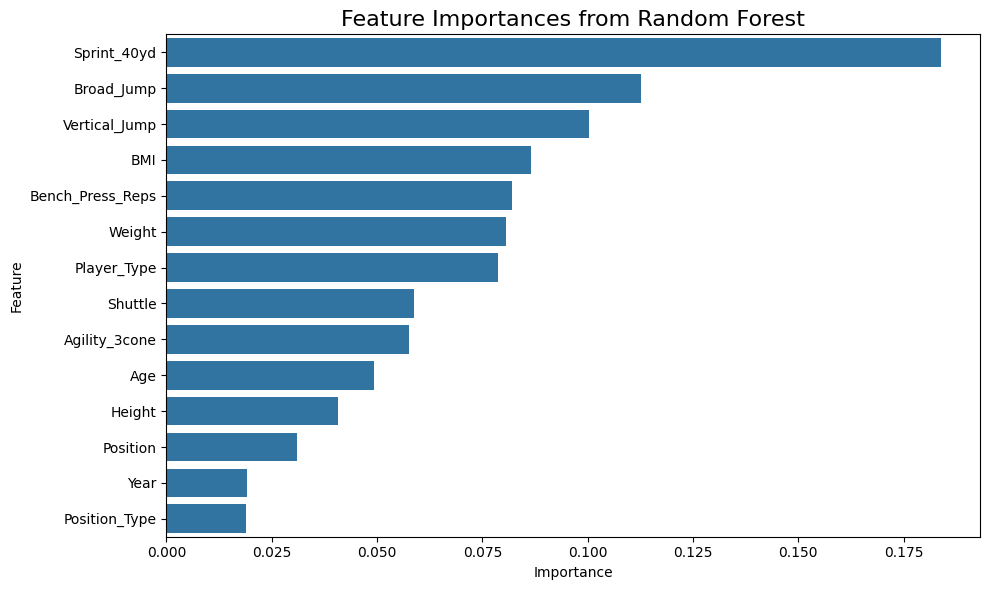

In [ ]:
# 特徴量とその重要度をDataFrameにまとめる
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 可視化
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

　新たに作った特徴量「BMI」列は、重要度は比較的高いことが分かりました。

In [ ]:
train6 = train5
test6 = test5

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

# --- 1. 欠損値補完 (これまでの工程) ---
# Age
age_means = train6.groupby('Year')['Age'].mean()
def fill_age(row): return age_means.get(row['Year'], row['Age']) if pd.isnull(row['Age']) else row['Age']
train6['Age'] = train6.apply(fill_age, axis=1)
test6['Age'] = test6.apply(fill_age, axis=1)

# Weight Group imputation
train6['Weight_Group'], bins_w = pd.qcut(train6['Weight'], q=10, retbins=True, labels=False)
for col in ['Sprint_40yd', 'Agility_3cone', 'Shuttle']:
    means = train6.groupby('Weight_Group')[col].mean()
    def fill_w(row):
        if pd.isnull(row[col]):
            idx = pd.cut([row['Weight']], bins=bins_w, labels=False, include_lowest=True)[0]
            return means[idx] if pd.notnull(idx) else means.mean()
        return row[col]
    train6[col] = train6.apply(fill_w, axis=1)
    test6[col] = test6.apply(fill_w, axis=1)
train6.drop(columns=['Weight_Group'], inplace=True)

# Sprint Group imputation for Jumps
train6['Sprint_Group'], bins_s = pd.qcut(train6['Sprint_40yd'], q=10, retbins=True, labels=False)
for col in ['Vertical_Jump', 'Broad_Jump']:
    means = train6.groupby('Sprint_Group')[col].mean()
    def fill_s(row):
        if pd.isnull(row[col]):
            idx = pd.cut([row['Sprint_40yd']], bins=bins_s, labels=False, include_lowest=True)[0]
            return means[idx] if pd.notnull(idx) else means.mean()
        return row[col]
    train6[col] = train6.apply(fill_s, axis=1)
    test6[col] = test6.apply(fill_s, axis=1)
train6.drop(columns=['Sprint_Group'], inplace=True)

# Bench Press
pos_medians = train6.groupby('Position')['Bench_Press_Reps'].median()
g_median = train6['Bench_Press_Reps'].median()
def fill_bench(row): return pos_medians.get(row['Position'], g_median) if pd.isnull(row['Bench_Press_Reps']) else row['Bench_Press_Reps']
train6['Bench_Press_Reps'] = train6.apply(fill_bench, axis=1)
test6['Bench_Press_Reps'] = test6.apply(fill_bench, axis=1)

In [ ]:
# --- 2. 特徴量エンジニアリング (ここが重要) ---

# (1) BMI (正しい計算式: Weight / Height^2)
train6['BMI'] = train6['Weight'] / (train6['Height'] ** 2)
test6['BMI'] = test6['Weight'] / (test6['Height'] ** 2)

# (2) Momentum Proxy (運動量: 体重 / 40yd走タイム)
# 重いのに速い選手を高く評価する指標
train6['Momentum'] = train6['Weight'] / train6['Sprint_40yd']
test6['Momentum'] = test6['Weight'] / test6['Sprint_40yd']

# (3) Work Rate (仕事率: 体重 * 垂直跳び)
# 重い体を高く持ち上げるパワーを評価
train6['Work_Rate'] = train6['Weight'] * train6['Vertical_Jump']
test6['Work_Rate'] = test6['Weight'] * test6['Vertical_Jump']

# (4) School Count (大学の参加人数)
# Power 5などの強豪校かどうかの代理変数として機能
school_counts = pd.concat([train6['School'], test6['School']]).value_counts()
train6['School_Count'] = train6['School'].map(school_counts)
test6['School_Count'] = test6['School'].map(school_counts)

# (5) Position Relative Stats (ポジション内偏差値)
# 「そのポジションの中でどれだけ優れているか」を数値化
# これが非常に効きます
num_cols = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
for c in num_cols:
    stats = train6.groupby('Position')[c].agg(['mean', 'std'])
    def get_rel(row):
        if row['Position'] in stats.index:
            m, s = stats.loc[row['Position']]
            return (row[c] - m) / s if s > 0 else 0
        return 0
    train6[f'{c}_Rel'] = train6.apply(get_rel, axis=1)
    test6[f'{c}_Rel'] = test6.apply(get_rel, axis=1)

# --- 3. データ整形 ---
# 不要な列を削除
drop_cols = ['Id', 'Year', 'School', 'Player_Type', 'Position_Type']
X = train6.drop(columns=drop_cols + ['Drafted'])
y = train6['Drafted'] # 修正: 目的変数yはtrain6から取得

# Positionを数値化 (Label Encoding)
le = LabelEncoder()
all_pos = pd.concat([train6['Position'], test6['Position']]).unique()
le.fit(all_pos)
X['Position'] = le.transform(X['Position'])

X_test = test6.drop(columns=drop_cols) # X_testを定義
X_test['Position'] = le.transform(X_test['Position']) # X_testのPositionも数値化

# --- 4. 学習と評価 ---
model = HistGradientBoostingClassifier(random_state=42, max_iter=200, learning_rate=0.05)

# CVで評価
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for trn_idx, val_idx in folds.split(X, y):
    X_trn, y_trn = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model.fit(X_trn, y_trn)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

print(f"CV AUC Score: {roc_auc_score(y, oof_preds):.4f}")

CV AUC Score: 0.7040


In [ ]:
# ==========================================
# Step 2. 特徴量エンジニアリング
# ==========================================

# (1) BMI
train6['BMI'] = train6['Weight'] / (train6['Height'] ** 2)
test6['BMI'] = test6['Weight'] / (test6['Height'] ** 2)

# (2) Momentum Proxy (運動量: 体重 / 40yd走タイム)
train6['Momentum'] = train6['Weight'] / train6['Sprint_40yd']
test6['Momentum'] = test6['Weight'] / test6['Sprint_40yd']

# (3) Work Rate (仕事率: 体重 * 垂直跳び)
train6['Work_Rate'] = train6['Weight'] * train6['Vertical_Jump']
test6['Work_Rate'] = test6['Weight'] * test6['Vertical_Jump']

# (4) School Count (大学の参加人数)
school_counts = pd.concat([train6['School'], test6['School']]).value_counts()
train6['School_Count'] = train6['School'].map(school_counts)
test6['School_Count'] = test6['School'].map(school_counts)

# (5) Position Relative Stats (ポジション内偏差値)
num_cols = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
for c in num_cols:
    # Trainデータに基づいて統計量を算出
    stats = train6.groupby('Position')[c].agg(['mean', 'std'])

    def get_rel(row):
        if row['Position'] in stats.index:
            m, s = stats.loc[row['Position']]
            # 標準偏差が0の場合は0を返す
            return (row[c] - m) / s if s > 0 else 0
        return 0

    train6[f'{c}_Rel'] = train6.apply(get_rel, axis=1)
    test6[f'{c}_Rel'] = test6.apply(get_rel, axis=1)


# ==========================================
# Step 3. データ整形と学習
# ==========================================

# 不要な列を削除
drop_cols = ['Id', 'Year', 'School', 'Player_Type', 'Position_Type']
X = train6.drop(columns=drop_cols + ['Drafted'])
y = train6['Drafted']

# Positionの数値化
le = LabelEncoder()
all_pos = pd.concat([train6['Position'], test6['Position']]).unique()
le.fit(all_pos)
X['Position'] = le.transform(X['Position'])

# モデル学習 (パラメータを少し調整)
# max_iter(木の数)を増やし、正則化(l2_regularization)を少し加えて過学習を抑制
model = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=300,          # 木の数を増やす
    learning_rate=0.03,    # 学習率を少し下げる（丁寧に学習させる）
    max_depth=5,           # 木の深さを制限
    l2_regularization=1.0, # 正則化
    early_stopping=True
)

# CV評価
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for trn_idx, val_idx in folds.split(X, y):
    X_trn, y_trn = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model.fit(X_trn, y_trn)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

print(f"CV AUC Score: {roc_auc_score(y, oof_preds):.4f}")

CV AUC Score: 0.7108


In [ ]:
train7 = train6
test7 = test6

In [ ]:
# ==========================================
# Step 1. 欠損値補完
# ==========================================

# 1-1. Age: 年ごとの平均で埋める
age_means = train7.groupby('Year')['Age'].mean()
def fill_age(row): return age_means.get(row['Year'], row['Age']) if pd.isnull(row['Age']) else row['Age']
train7['Age'] = train7.apply(fill_age, axis=1)
test7['Age'] = test7.apply(fill_age, axis=1)

# 1-2. Sprint, Agility, Shuttle: 「体重」の連動性を利用して埋める
train7['Weight_Group'], bins_w = pd.qcut(train7['Weight'], q=10, retbins=True, labels=False)

for col in ['Sprint_40yd', 'Agility_3cone', 'Shuttle']:
    means = train7.groupby('Weight_Group')[col].mean()

    def fill_by_weight(row):
        if pd.isnull(row[col]):
            idx = pd.cut([row['Weight']], bins=bins_w, labels=False, include_lowest=True)[0]
            return means[idx] if pd.notnull(idx) else means.mean()
        return row[col]

    train7[col] = train7.apply(fill_by_weight, axis=1)
    test7[col] = test7.apply(fill_by_weight, axis=1)

train7.drop(columns=['Weight_Group'], inplace=True)

# 1-3. Jump系: 「Sprint_40yd」の連動性を利用して埋める
train7['Sprint_Group'], bins_s = pd.qcut(train7['Sprint_40yd'], q=10, retbins=True, labels=False)

for col in ['Vertical_Jump', 'Broad_Jump']:
    means = train7.groupby('Sprint_Group')[col].mean()

    def fill_by_sprint(row):
        if pd.isnull(row[col]):
            idx = pd.cut([row['Sprint_40yd']], bins=bins_s, labels=False, include_lowest=True)[0]
            return means[idx] if pd.notnull(idx) else means.mean()
        return row[col]

    train7[col] = train7.apply(fill_by_sprint, axis=1)
    test7[col] = test7.apply(fill_by_sprint, axis=1)

train7.drop(columns=['Sprint_Group'], inplace=True)

# 1-4. Bench Press: 「Position」ごとの中央値で埋める
pos_medians = train7.groupby('Position')['Bench_Press_Reps'].median()
global_median = train7['Bench_Press_Reps'].median()

def fill_bench(row):
    return pos_medians.get(row['Position'], global_median) if pd.isnull(row['Bench_Press_Reps']) else row['Bench_Press_Reps']

train7['Bench_Press_Reps'] = train7.apply(fill_bench, axis=1)
test7['Bench_Press_Reps'] = test7.apply(fill_bench, axis=1)


# ==========================================
# Step 2. 特徴量エンジニアリング
# ==========================================

# (1) BMI
train7['BMI'] = train7['Weight'] / (train7['Height'] ** 2)
test7['BMI'] = test7['Weight'] / (test7['Height'] ** 2)

# (2) Momentum Proxy (運動量)
train7['Momentum'] = train7['Weight'] / train7['Sprint_40yd']
test7['Momentum'] = test7['Weight'] / test7['Sprint_40yd']

# (3) Work Rate (仕事率)
train7['Work_Rate'] = train7['Weight'] * train7['Vertical_Jump']
test7['Work_Rate'] = test7['Weight'] * test7['Vertical_Jump']

# (4) School Count
school_counts = pd.concat([train7['School'], test7['School']]).value_counts()
train7['School_Count'] = train7['School'].map(school_counts)
test7['School_Count'] = test7['School'].map(school_counts)

# (5) Position Relative Stats (ポジション内偏差値)
num_cols = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']
for c in num_cols:
    stats = train7.groupby('Position')[c].agg(['mean', 'std'])

    def get_rel(row):
        if row['Position'] in stats.index:
            m, s = stats.loc[row['Position']]
            return (row[c] - m) / s if s > 0 else 0
        return 0

    train7[f'{c}_Rel'] = train7.apply(get_rel, axis=1)
    test7[f'{c}_Rel'] = test7.apply(get_rel, axis=1)


# ==========================================
# Step 3. データ整形と学習
# ==========================================

drop_cols = ['Id', 'Year', 'School', 'Player_Type', 'Position_Type']
X = train7.drop(columns=drop_cols + ['Drafted'])
y = train7['Drafted']

# Positionの数値化
le = LabelEncoder()
all_pos = pd.concat([train7['Position'], test7['Position']]).unique()
le.fit(all_pos)
X['Position'] = le.transform(X['Position'])

# テストデータ予測用 (提出用データの作成準備)
X_test = test7.drop(columns=drop_cols)
X_test['Position'] = le.transform(X_test['Position'])

# モデル学習 (0.8155が出た設定)
model = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=200,
    learning_rate=0.05,
    early_stopping=True
)

# CV評価
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for trn_idx, val_idx in folds.split(X, y):
    X_trn, y_trn = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model.fit(X_trn, y_trn)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

print(f"CV AUC Score: {roc_auc_score(y, oof_preds):.4f}")

CV AUC Score: 0.7049


In [ ]:
# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

In [ ]:
# 特徴量と目的変数に分ける
X = train5.drop(columns=["Drafted"])
y = train5["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア・予測格納用
auc_scores = []
test_pred_proba_list = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # バリデーション予測 & スコア
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

    # テストデータ予測を保存
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

## 7. 提出ファイル作成

In [ ]:
# このセルを実行すると提出用のCSVファイルが作成されます
submission = pd.read_csv(PATH + 'sample_submission.csv') # PATHは必要に応じて変更の必要があります
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'baseline_submission.csv', index=False)

　ここまでで、提出可能な予測CSVファイルを作成することができました。「baseline_submission.csv」を提出してみましょう。

#２回目

##処理

Ageの欠損値を見ると、ドラフトされていない人が多かった。

以下にAgeの欠損値でドラフトとされた人を示す

In [ ]:
d = train
t = test

In [ ]:
d = train[train["Age"].isna()]
d[d["Drafted"] == 1]

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
490,2009,NaN,1.8288,138.799265,5.08,76.20,37.0,264.16,7.78,5.06,defense,defensive_lineman,DT,1.0
706,2009,NaN,1.9304,113.851685,4.63,78.74,22.0,287.02,7.31,4.58,defense,defensive_lineman,DE,1.0
1620,2010,NaN,1.8796,97.522360,4.59,91.44,21.0,314.96,6.94,4.15,defense,defensive_back,SS,1.0
2136,2009,NaN,1.8542,108.408576,4.51,93.98,30.0,287.02,6.98,4.12,defense,line_backer,OLB,1.0
2280,2010,NaN,1.8796,91.625659,4.80,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,P,1.0
2392,2012,NaN,1.9050,129.273825,5.01,78.74,NaN,266.70,7.45,4.53,defense,defensive_lineman,DE,1.0
2574,2015,NaN,1.9050,117.934016,4.74,74.93,19.0,254.00,7.56,4.53,defense,line_backer,OLB,1.0
2681,2009,NaN,1.8288,90.264882,4.35,80.01,NaN,297.18,NaN,NaN,offense,backs_receivers,WR,1.0


６つのカラムに欠損値が見られるデータがあるので、データ数次第で削除する。

In [ ]:
# --- Trainデータでの抽出 ---
# 行ごとの欠損値をカウントし、7以上の行を抽出
train_missing_6plus = d[d.isnull().sum(axis=1) >= 7]

print(f"欠損が7個以上あるTrainデータ数: {len(train_missing_6plus)}")
display(train_missing_6plus.head())  # 先頭を表示

# --- Testデータでの抽出 ---
# 行ごとの欠損値をカウントし、7以上の行を抽出
test_missing_6plus = t[t.isnull().sum(axis=1) >= 7]

print(f"欠損が7個以上あるTestデータ数: {len(test_missing_6plus)}")
display(test_missing_6plus.head())   # 先頭を表示

欠損が7個以上あるTrainデータ数: 11


,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
169,2019,NaN,1.9304,112.944500,NaN,NaN,NaN,NaN,NaN,NaN,offense,backs_receivers,TE,0.0
231,2019,NaN,1.9558,151.953444,NaN,NaN,NaN,NaN,NaN,NaN,offense,offensive_lineman,OT,0.0
361,2018,NaN,1.8288,83.914588,NaN,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,K,0.0
797,2019,NaN,1.7018,78.471480,NaN,NaN,NaN,NaN,NaN,NaN,offense,backs_receivers,WR,0.0
1669,2018,NaN,2.0066,105.233430,NaN,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,P,0.0


欠損が7個以上あるTestデータ数: 8


,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position
28,2010,NaN,1.8542,94.800805,NaN,NaN,NaN,NaN,NaN,NaN,special_teams,kicking_specialist,K
101,2019,NaN,1.8288,93.440028,NaN,NaN,NaN,NaN,NaN,NaN,defense,defensive_back,S
207,2018,NaN,1.7780,79.378665,NaN,NaN,NaN,NaN,NaN,NaN,defense,defensive_back,CB
343,2019,NaN,1.9304,142.428004,NaN,NaN,NaN,NaN,NaN,NaN,offense,offensive_lineman,OT
385,2018,NaN,1.9558,139.252858,NaN,NaN,NaN,NaN,NaN,NaN,offense,offensive_lineman,OT


データ数がそこまで多くないので訓練データを削除する。

In [ ]:
# --- Trainデータの処理 ---
print(f"削除前のTrainデータ行数: {len(d)}")

# 欠損値が6個以上の行を削除（＝欠損値が6個未満の行を残す）
d1 = d[d.isnull().sum(axis=1) < 7]

print(f"削除後のTrainデータ行数: {len(d1)}")

# --- (参考) Testデータの処理について ---
# Testデータは行を削除すると提出できなくなる恐れがあるため、
# 通常は削除しません。もし分析目的等でどうしても削除したい場合は
# 以下のコメントアウト(#)を外して実行してください。
# test_df = test_df[test_df.isnull().sum(axis=1) < 7]

削除前のTrainデータ行数: 2781
削除後のTrainデータ行数: 2770


In [ ]:
d1.isnull().sum()

,0
Year,0
Age,424
Height,0
Weight,0
Sprint_40yd,134
Vertical_Jump,543
Bench_Press_Reps,710
Broad_Jump,570
Agility_3cone,959
Shuttle,901


In [ ]:
# データの読み込み
d2 = d1
t1 = t

# Ageの補完（先ほどの手順）
age_mean_by_year = d2.groupby('Year')['Age'].mean()
def fill_age(row, source_means):
    if pd.isnull(row['Age']):
        return source_means.get(row['Year'], row['Age'])
    return row['Age']
d2['Age'] = d2.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)
t1['Age'] = t1.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)


# --- ここから他の列の補完 ---

# 欠損がある数値列のリスト
numeric_cols_with_nan = [
    'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
    'Broad_Jump', 'Agility_3cone', 'Shuttle'
]

# 各列の中央値(median)で埋める
# ポイント: Testデータも「Trainデータの中央値」で埋めます（データリーク防止）
for col in numeric_cols_with_nan:
    # Trainの中央値を算出
    median_val = d2[col].median()

    # TrainとTestの欠損を埋める
    d2[col] = d2[col].fillna(median_val)
    t1[col] = t1[col].fillna(median_val)

# 確認
print("Trainデータの欠損数:\n", d2.isnull().sum())
print("Testデータの欠損数:\n", t1.isnull().sum())

Trainデータの欠損数:
 Year                0
Age                 0
Height              0
Weight              0
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
Player_Type         0
Position_Type       0
Position            0
Drafted             0
dtype: int64
Testデータの欠損数:
 Year                0
Age                 0
Height              0
Weight              0
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
Player_Type         0
Position_Type       0
Position            0
dtype: int64


/tmp/ipython-input-770790374.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2['Age'] = d2.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)
/tmp/ipython-input-770790374.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2[col] = d2[col].fillna(median_val)


##確認

In [ ]:
d2.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [ ]:
t1.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [ ]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770 entries, 0 to 2780
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2770 non-null   int64  
 1   Age               2770 non-null   float64
 2   Height            2770 non-null   float64
 3   Weight            2770 non-null   float64
 4   Sprint_40yd       2770 non-null   float64
 5   Vertical_Jump     2770 non-null   float64
 6   Bench_Press_Reps  2770 non-null   float64
 7   Broad_Jump        2770 non-null   float64
 8   Agility_3cone     2770 non-null   float64
 9   Shuttle           2770 non-null   float64
 10  Player_Type       2770 non-null   object 
 11  Position_Type     2770 non-null   object 
 12  Position          2770 non-null   object 
 13  Drafted           2770 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 324.6+ KB


In [ ]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    d2[c] = label_encoders[c].fit_transform(d2[c].astype(str))
    t1[c] = label_encoders[c].transform(t1[c].astype(str))

/tmp/ipython-input-3176771294.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2[c] = label_encoders[c].fit_transform(d2[c].astype(str))
/tmp/ipython-input-3176771294.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d2[c] = label_encoders[c].fit_transform(d2[c].astype(str))
/tmp/ipython-input-3176771294.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [ ]:
# 数値型に変換
d2 = d2.astype({"Age": "int64"})
t1 = t1.astype({"Age": "int64"})

In [ ]:
d2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770 entries, 0 to 2780
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2770 non-null   int64  
 1   Age               2770 non-null   int64  
 2   Height            2770 non-null   float64
 3   Weight            2770 non-null   float64
 4   Sprint_40yd       2770 non-null   float64
 5   Vertical_Jump     2770 non-null   float64
 6   Bench_Press_Reps  2770 non-null   float64
 7   Broad_Jump        2770 non-null   float64
 8   Agility_3cone     2770 non-null   float64
 9   Shuttle           2770 non-null   float64
 10  Player_Type       2770 non-null   int64  
 11  Position_Type     2770 non-null   int64  
 12  Position          2770 non-null   int64  
 13  Drafted           2770 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 324.6 KB


##分析

In [ ]:
# 特徴量と目的変数に分ける
X = d2.drop(columns=["Drafted"])
y = d2["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.6478
Fold 2
  AUC: 0.7245
Fold 3
  AUC: 0.7426
Fold 4
  AUC: 0.6798
Fold 5
  AUC: 0.7143

Average Validation AUC: 0.7018


#3回目

##処理

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   int64  
 13  Position_Type     2781 non-null   int64  
 14  Position          2781 non-null   int64  
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(5), object(1)
memory

In [ ]:
# 使わない列の削除
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id","School"])

In [ ]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

##分析

In [ ]:
# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.7914
Fold 2
  AUC: 0.8293
Fold 3
  AUC: 0.8504
Fold 4
  AUC: 0.7776
Fold 5
  AUC: 0.8397

Average Validation AUC: 0.8177


In [ ]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [ ]:
# 特徴量と目的変数に分ける
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア・予測格納用
auc_scores = []
test_pred_proba_list = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # バリデーション予測 & スコア
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

    # テストデータ予測を保存
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

# テスト予測の平均を計算
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

Fold 1
  AUC: 0.7832
Fold 2
  AUC: 0.8479
Fold 3
  AUC: 0.8563
Fold 4
  AUC: 0.783
Fold 5
  AUC: 0.8316

Average Validation AUC: 0.8204


#4回目

In [ ]:
train1 = train
test1 = test

# 1. Trainデータをもとに、年度(Year)ごとのAgeの平均値を算出
age_mean_by_year = train1.groupby('Year')['Age'].mean()

# 2. 欠損値を補完する関数を定義
def fill_age(row, source_means):
    # Ageが欠損(NaN)の場合
    if pd.isnull(row['Age']):
        # その年度の平均値を返す（万が一その年度が辞書にない場合は元のNaNを返す）
        return source_means.get(row['Year'], row['Age'])
    # 欠損していない場合はそのままの値を返す
    return row['Age']

# 3. Trainデータへの適用
train1['Age'] = train1.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)

# 4. Testデータへの適用（Trainデータの平均値を使用）
test1['Age'] = test1.apply(lambda row: fill_age(row, age_mean_by_year), axis=1)

# 確認
print("TrainデータのAge欠損数:", train1['Age'].isnull().sum())
print("TestデータのAge欠損数:", test1['Age'].isnull().sum())

TrainデータのAge欠損数: 0
TestデータのAge欠損数: 0


In [ ]:
# 数値型に変換
train1 = train1.astype({"Age": "int64"})
test1 = test1.astype({"Age": "int64"})

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2781 non-null   int64  
 1   Age               2781 non-null   int64  
 2   Height            2781 non-null   float64
 3   Weight            2781 non-null   float64
 4   Sprint_40yd       2636 non-null   float64
 5   Vertical_Jump     2227 non-null   float64
 6   Bench_Press_Reps  2060 non-null   float64
 7   Broad_Jump        2200 non-null   float64
 8   Agility_3cone     1811 non-null   float64
 9   Shuttle           1869 non-null   float64
 10  Player_Type       2781 non-null   int64  
 11  Position_Type     2781 non-null   int64  
 12  Position          2781 non-null   int64  
 13  Drafted           2781 non-null   float64
 14  BMI               2781 non-null   float64
dtypes: float64(10), int64(5)
memory usage: 326.0 KB


In [ ]:
# 特徴量と目的変数に分ける
X = train1.drop(columns=["Drafted"])
y = train1["Drafted"]

# モデルとCVの設定
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# スコア格納用
auc_scores = []

# Stratified K-Fold による学習と評価
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # モデル学習
    model.fit(X_train, y_train)

    # 予測とスコアリング
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# 平均AUCを表示
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.6582
Fold 2
  AUC: 0.7437
Fold 3
  AUC: 0.7634
Fold 4
  AUC: 0.6795
Fold 5
  AUC: 0.6711

Average Validation AUC: 0.7032


Ageの欠損値処理をしたがスコアが下がった